# Table of Contents
- [EDA for the Datasets](#eda-for-the-datasets)
  - [Data Inspection](#data-inspection)
  - [Data Preparation](#data-preparation)
    - [Feature Engineering: Account Roles and Time](#feature-engineering-account-roles-and-time)
    - [Drop Unnecessary ID Columns](#drop-unnecessary-id-columns)
  - [Data Visualization](#data-visualization)
    - [Univariate Visualization](#univariate-visualization)
      - [Transaction Type Distribution](#transaction-type-distribution)
      - [Transaction Amount Outliers](#transaction-amount-outliers)
      - [Origin and Destination Type Distribution](#origin-and-destination-type-distribution)
      - [Balance Columns Distribution](#balance-columns-distribution)
      - [Day of Month Distribution](#day-of-month-distribution)
    - [Target Variable Analysis](#target-variable-analysis)
      - [Fraud Distribution (Target Variable)](#fraud-distribution-target-variable)
    - [Bivariate Analysis](#bivariate-analysis)
      - [Amount vs Transaction Type Boxplot](#amount-vs-transaction-type-boxplot)
      - [Transaction Type vs Account Types](#transaction-type-vs-account-types)
      - [Legitimate vs Fraud Transactions](#legitimate-vs-fraud-transactions)
      - [Fraud Transaction Distribution vs Time of Day](#fraud-transaction-distribution-vs-time-of-day)
        - [Note: Fraudulent transactions occur continuously across all hours](#note-fraudulent-transactions-occur-continuously-across-all-hours)
      - [Legitimate Transaction Distribution vs Time of Day](#legitimate-transaction-distribution-vs-time-of-day)
      - [Relationship Between Amount and Old Balance in Fraud Cases](#relationship-between-amount-and-old-balance-in-fraud-cases)
      
  - [Data preprocessing](#data-preprocessing)
    - [Encoding](#encoding)
    - [Data Scaling](#data-scaling)
    - [Correlation Matrix](#correlation-matrix)
    - [Principal Component Analysis (PCA)](#principal-component-analysis-pca)
    - [KMeans Clustering](#kmeans-clustering)
    - [Train-Test Split](#train-test-split)


# EDA for the Datasets

## Data Inspection


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [28]:
## explore the dataset
df = pd.read_csv('PS_20174392719_1491204439457_log.csv')
df.head()
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

## Data Preparation


### Feature Engineering: Account Roles and Time


In [29]:
# let's add new column that tell about the origins and destination type
df['OrigType'] = df['nameOrig'].str[0]
df['DestType'] = df['nameDest'].str[0]
df['hour_of_day'] = df['step'] % 24
df['day_of_month'] = (df['step'] // 24) % 30

### Drop Unnecessary ID Columns


In [30]:
column_to_drop = ['nameOrig', 'nameDest', 'step']
df = df.drop(columns=column_to_drop)

## Data Visualization


### Univariate Visualization


#### Transaction Type Distribution


C:\Users\DCS\AppData\Local\Temp\ipykernel_17440\1769898389.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='Set2')


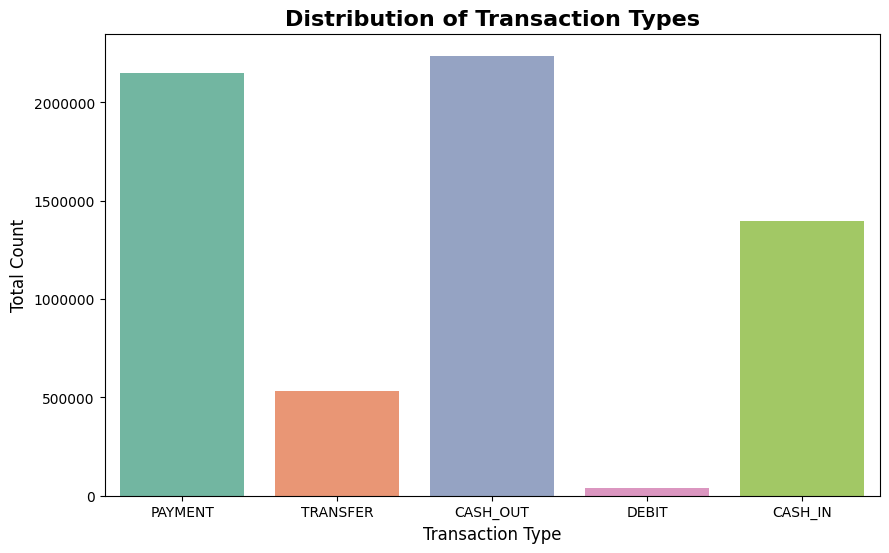

In [31]:
plt.figure(figsize=(10, 6))

sns.countplot(x='type', data=df, palette='Set2')

plt.title('Distribution of Transaction Types', fontsize=16, fontweight='bold')
plt.xlabel('Transaction Type', fontsize=12)
plt.ylabel('Total Count', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

#### Transaction Amount Outliers


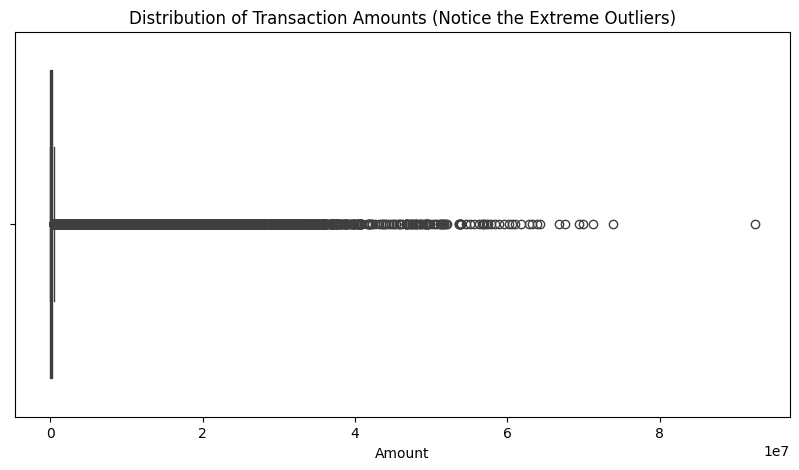

In [32]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['amount'])
plt.title('Distribution of Transaction Amounts (Notice the Extreme Outliers)')
plt.xlabel('Amount')
plt.show()

#### Origin and Destination Type Distribution


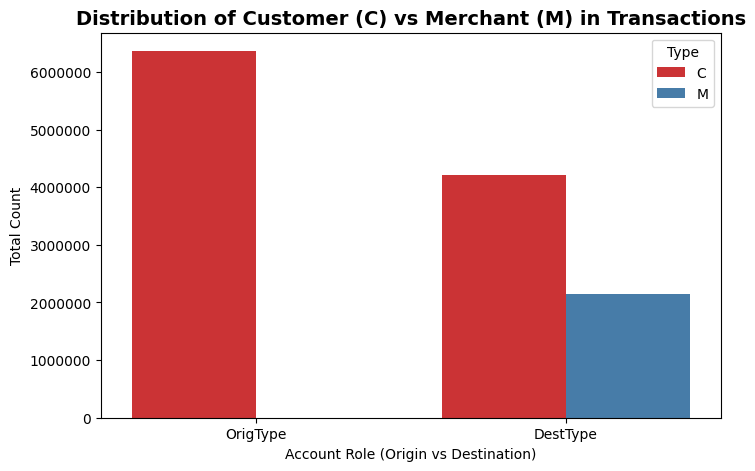

In [33]:
types_df = df[['OrigType', 'DestType']].melt(var_name='Role', value_name='Type')
plt.figure(figsize=(8, 5))
sns.countplot(x='Role', hue='Type', data=types_df, palette='Set1')
plt.title('Distribution of Customer (C) vs Merchant (M) in Transactions', fontsize=14, fontweight='bold')
plt.ylabel('Total Count')
plt.xlabel('Account Role (Origin vs Destination)')
plt.ticklabel_format(style='plain', axis='y')

plt.show()

#### Balance Columns Distribution


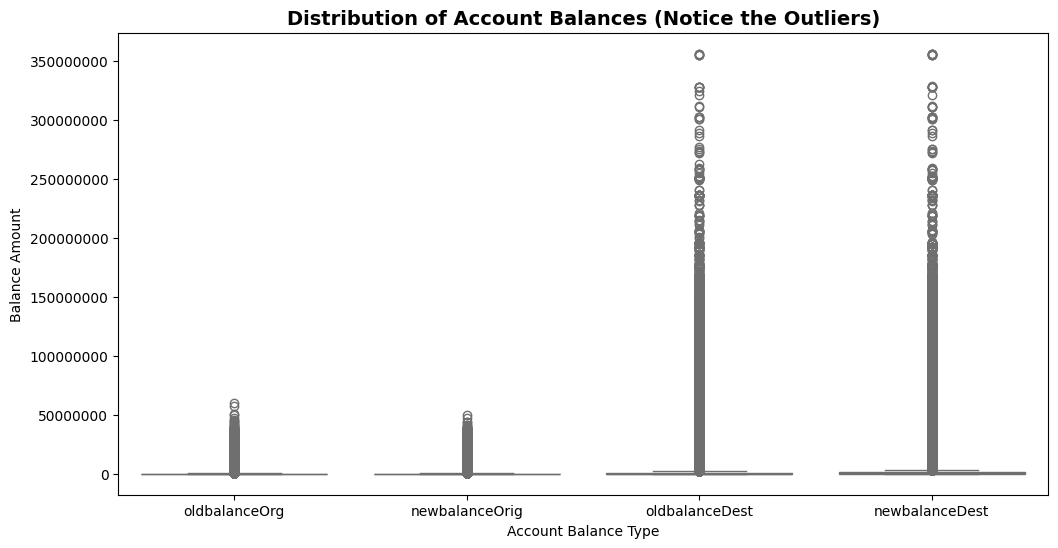

In [34]:
plt.figure(figsize=(12, 6))

balances = df[['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']]
sns.boxplot(data=balances, palette='pastel')
plt.title('Distribution of Account Balances (Notice the Outliers)', fontsize=14, fontweight='bold')
plt.ylabel('Balance Amount')
plt.xlabel('Account Balance Type')
plt.ticklabel_format(style='plain', axis='y')

plt.show()

#### Day of Month Distribution


C:\Users\DCS\AppData\Local\Temp\ipykernel_17440\2332078163.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='day_of_month', data=df, palette='viridis')


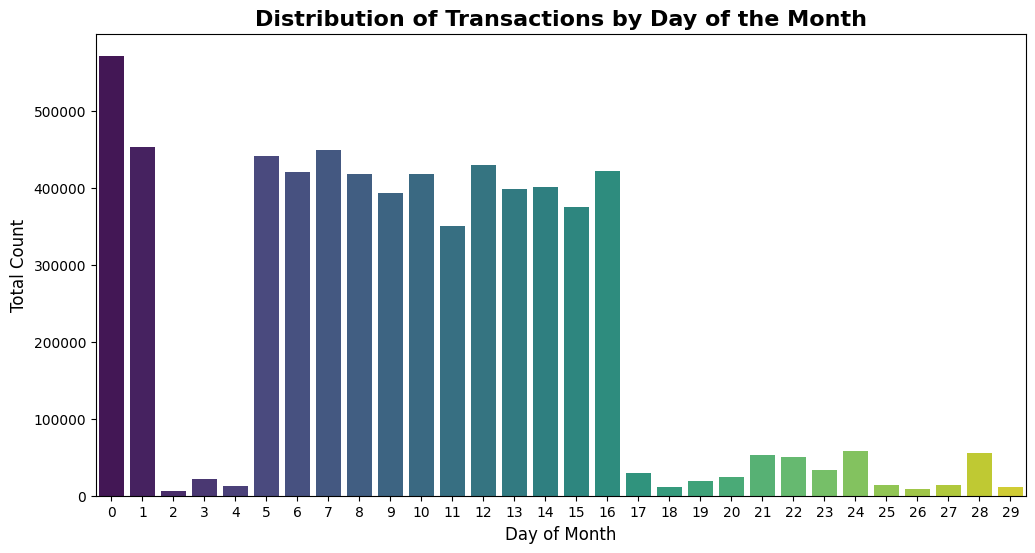

In [35]:
plt.figure(figsize=(12, 6))
sns.countplot(x='day_of_month', data=df, palette='viridis')
plt.title('Distribution of Transactions by Day of the Month', fontsize=16, fontweight='bold')
plt.xlabel('Day of Month', fontsize=12)
plt.ylabel('Total Count', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.show()


### Target Variable Analysis


#### Fraud Distribution (Target Variable)


C:\Users\DCS\AppData\Local\Temp\ipykernel_17440\2695608369.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='isFraud', palette='Set2')


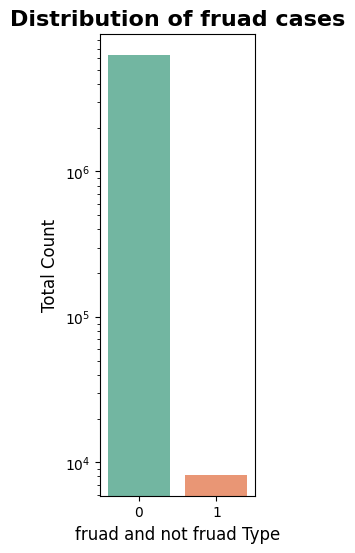

In [36]:
plt.figure(figsize=(2, 6))

sns.countplot(data=df, x='isFraud', palette='Set2')
plt.title('Distribution of fruad cases', fontsize=16, fontweight='bold')
plt.xlabel('fruad and not fruad Type', fontsize=12)
plt.ylabel('Total Count', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.yscale('log')
plt.show()

### Bivariate Analysis

#### Amount vs Transaction Type Boxplot


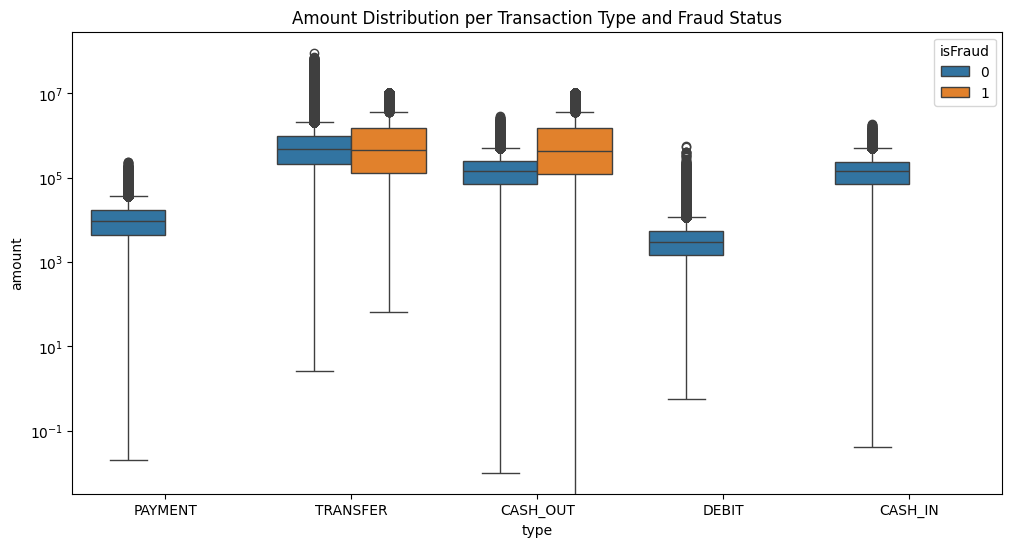

In [37]:
plt.figure(figsize=(12, 6))

sns.boxplot(x='type', y='amount', hue='isFraud', data=df)
plt.yscale('log') 
plt.title('Amount Distribution per Transaction Type and Fraud Status')
plt.show()

#### Transaction Type vs Account Types
This section visualizes the relationship between the type of transaction and the origin/destination account types (Customer vs Merchant).


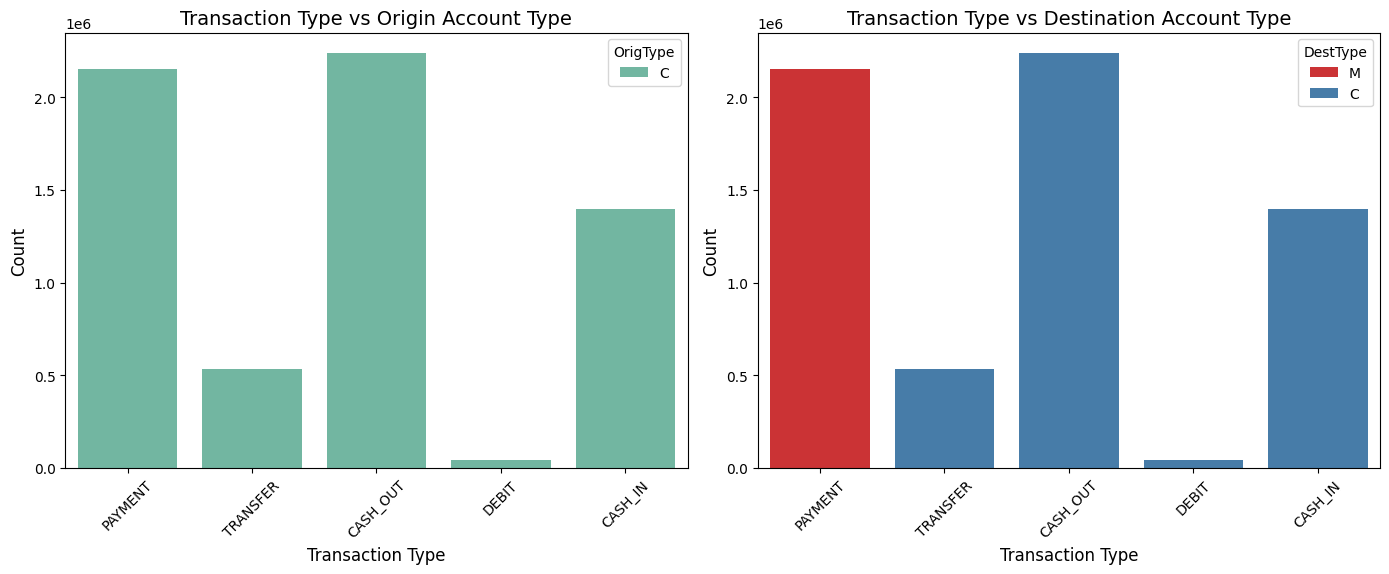

In [38]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='type', hue='OrigType', palette='Set2')
plt.title('Transaction Type vs Origin Account Type', fontsize=14)
plt.xlabel('Transaction Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='type', hue='DestType', palette='Set1')
plt.title('Transaction Type vs Destination Account Type', fontsize=14)
plt.xlabel('Transaction Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


#### Legitimate vs Fraud Transactions


C:\Users\DCS\AppData\Local\Temp\ipykernel_17440\3817365592.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['isFraud'] == 0]['hour_of_day'], label='Legitimate', shade=True)
C:\Users\DCS\AppData\Local\Temp\ipykernel_17440\3817365592.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['isFraud'] == 1]['hour_of_day'], label='Fraud', shade=True)


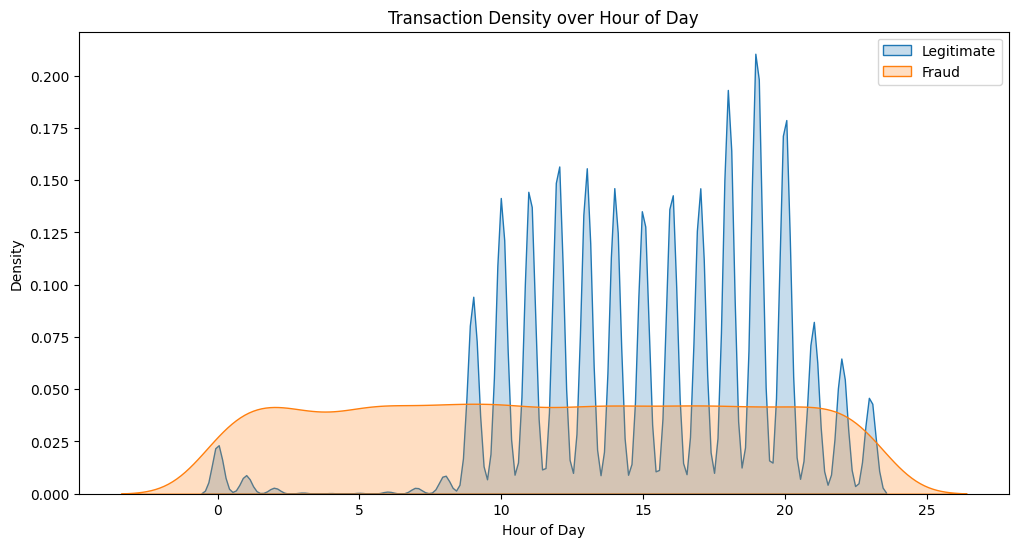

In [39]:
plt.figure(figsize=(12, 6))

sns.kdeplot(data=df[df['isFraud'] == 0]['hour_of_day'], label='Legitimate', shade=True)
sns.kdeplot(data=df[df['isFraud'] == 1]['hour_of_day'], label='Fraud', shade=True)
plt.title('Transaction Density over Hour of Day')
plt.xlabel('Hour of Day')
plt.legend()
plt.show()

#### Fraud Transaction Distribution vs Time of Day


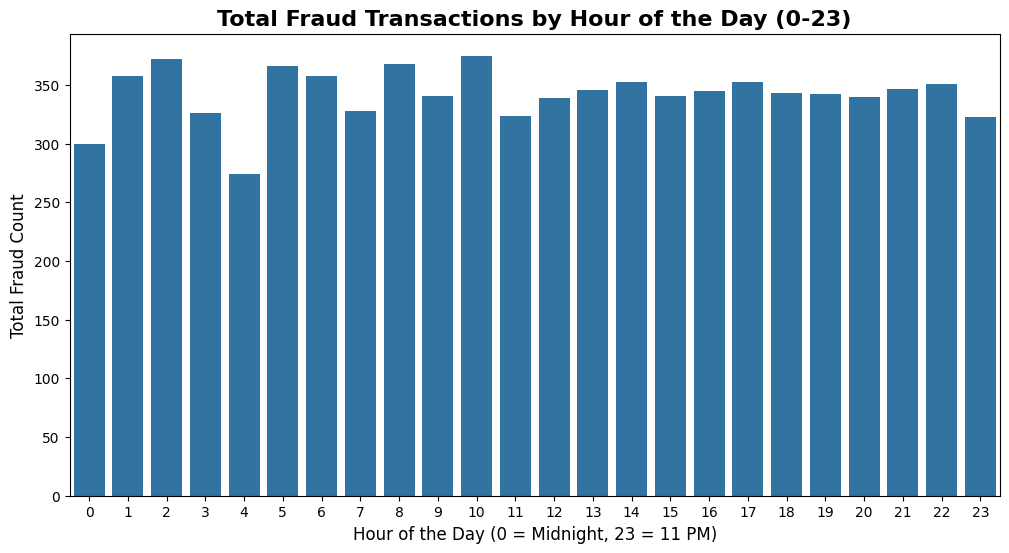

In [40]:


fraud_data = df[df['isFraud'] == 1]

fraud_counts_per_hour = fraud_data.groupby('hour_of_day').size().reset_index(name='fraud_count')

plt.figure(figsize=(12, 6))
sns.barplot(data=fraud_counts_per_hour, x='hour_of_day', y='fraud_count')

plt.title('Total Fraud Transactions by Hour of the Day (0-23)', fontsize=16, fontweight='bold')
plt.xlabel('Hour of the Day (0 = Midnight, 23 = 11 PM)', fontsize=12)
plt.ylabel('Total Fraud Count', fontsize=12)

plt.xticks(range(0, 24))

plt.show()

##### Note: Fraudulent transactions occur continuously across all hours


#### Legitimate Transaction Distribution vs Time of Day


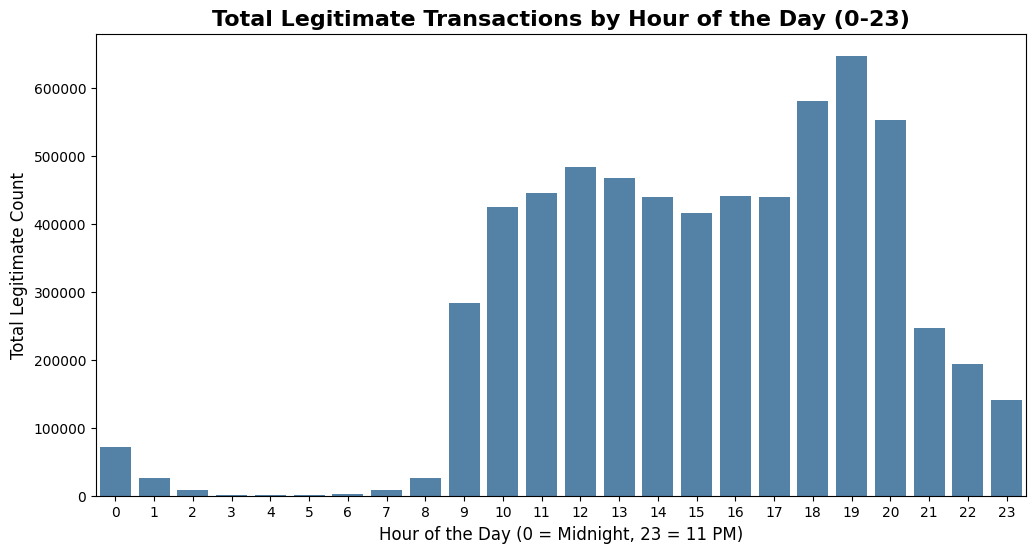

In [41]:
legit_data = df[df['isFraud'] == 0]

legit_counts_per_hour = legit_data.groupby('hour_of_day').size().reset_index(name='legit_count')

plt.figure(figsize=(12, 6))

sns.barplot(data=legit_counts_per_hour, x='hour_of_day', y='legit_count', color='steelblue')

plt.title('Total Legitimate Transactions by Hour of the Day (0-23)', fontsize=16, fontweight='bold')
plt.xlabel('Hour of the Day (0 = Midnight, 23 = 11 PM)', fontsize=12)
plt.ylabel('Total Legitimate Count', fontsize=12)

plt.ticklabel_format(style='plain', axis='y')
plt.xticks(range(0, 24))

plt.show()

#### Relationship Between Amount and Old Balance in Fraud Cases


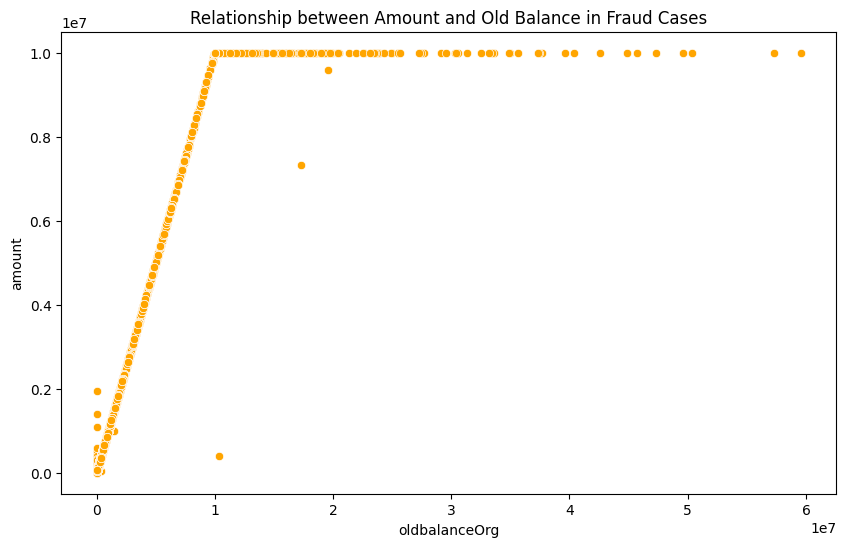

In [42]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x='oldbalanceOrg', y='amount', data=df[df['isFraud'] == 1], color='orange')
plt.title('Relationship between Amount and Old Balance in Fraud Cases')
plt.show()

In [43]:
df.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,OrigType,DestType,hour_of_day,day_of_month
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0,C,M,1,0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0,C,M,1,0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0,C,C,1,0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0,C,C,1,0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0,C,M,1,0


#### Day of Month vs Fraud


## Data preprocessing

### Encoding

In [44]:

df = df.drop(columns=['OrigType'])

df['DestType'] = df['DestType'].map({'C': 0, 'M': 1})

df = pd.get_dummies(df, columns=['type'], drop_first=True, dtype=int)

df.head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,DestType,hour_of_day,day_of_month,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,9839.64,170136.0,160296.36,0.0,0.0,0,0,1,1,0,0,0,1,0
1,1864.28,21249.0,19384.72,0.0,0.0,0,0,1,1,0,0,0,1,0
2,181.00,181.0,0.00,0.0,0.0,1,0,0,1,0,0,0,0,1
3,181.00,181.0,0.00,21182.0,0.0,1,0,0,1,0,1,0,0,0
4,11668.14,41554.0,29885.86,0.0,0.0,0,0,1,1,0,0,0,1,0


### Data Scaling

In [45]:
cols_to_scale = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

scaler = RobustScaler() # x_scaled = (x - Q2) / (Q3 - Q1)

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

df[cols_to_scale].head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
0,-0.332932,1.452991,1.111175,-0.140722,-0.193057
1,-0.373762,0.065610,0.134375,-0.140722,-0.193057
2,-0.382380,-0.130708,0.000000,-0.140722,-0.193057
3,-0.382380,-0.130708,0.000000,-0.118260,-0.193057
4,-0.323571,0.254820,0.207169,-0.140722,-0.193057


### Correlation Matrix

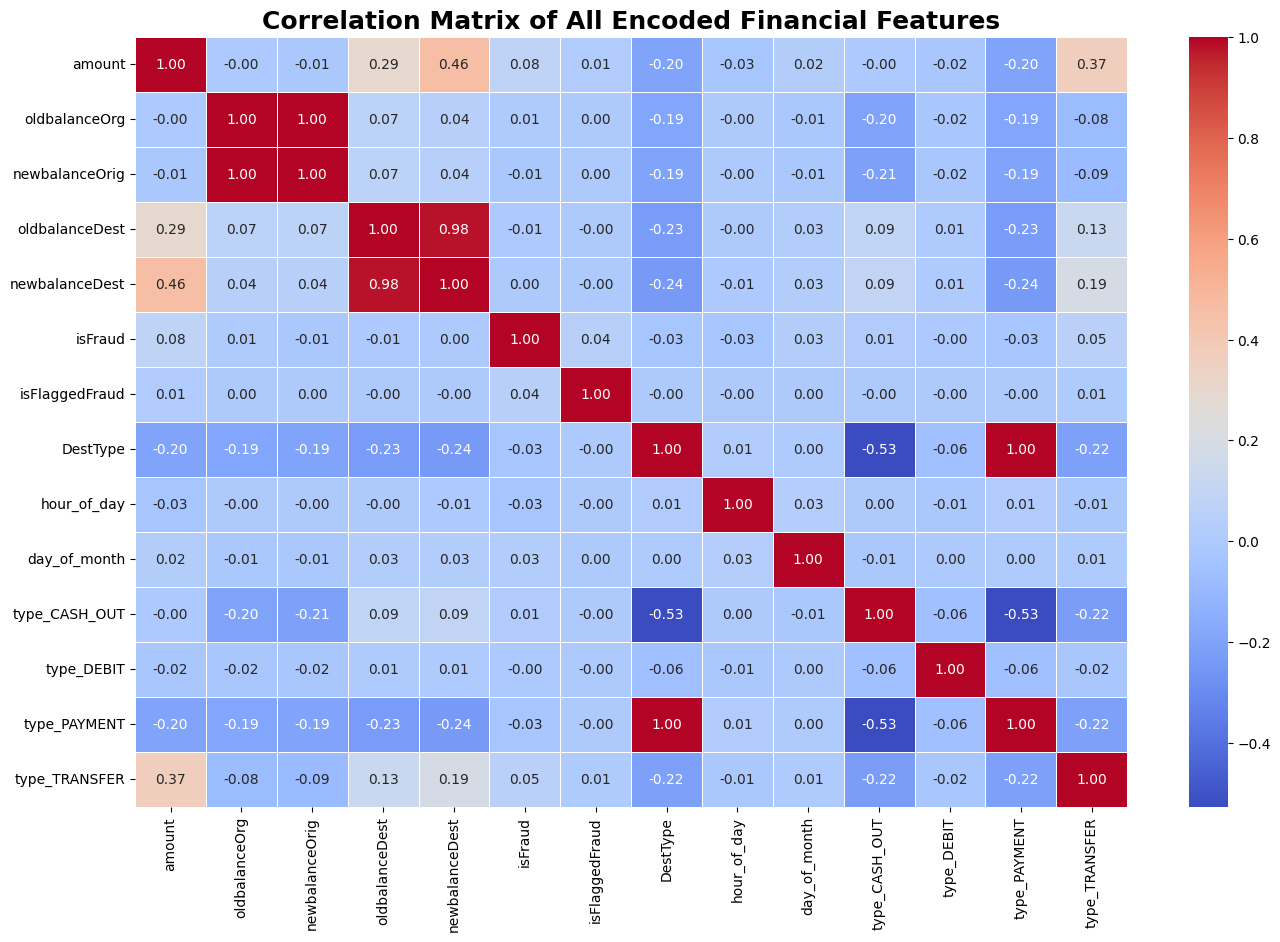

In [46]:

plt.figure(figsize=(16, 10))

corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix of All Encoded Financial Features', fontsize=18, fontweight='bold')

plt.show()

The correlation matrix reveals significant multicollinearity among financial features, specifically between account balance pairs (Origin and Destination), with coefficients approaching 1.0. This redundancy provides a strong mathematical justification for applying Principal Component Analysis (PCA) to reduce dimensionality and eliminate noise. Additionally, the weak linear correlation between individual features and the target variable (isFraud) suggests that fraudulent patterns are non-linear and complex, necessitating the use of advanced ensemble models like XGBoost for effective detection.

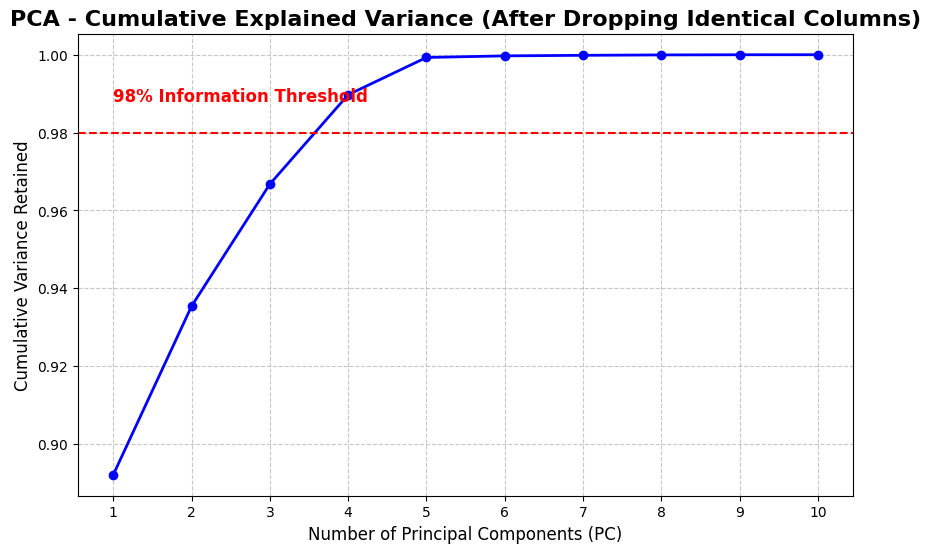

In [47]:

X = df.drop(columns=['isFraud', 'isFlaggedFraud'])
y = df['isFraud']

corr_matrix = X.corr().abs()

corr_matrix = X.corr().abs()

columns_to_drop = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        
        if corr_matrix.iloc[i, j] > 0.99:
            colname = corr_matrix.columns[j]
            columns_to_drop.add(colname)

columns_to_drop = list(columns_to_drop)

X_filtered = X.drop(columns=columns_to_drop)

pca_test = PCA()
pca_test.fit(X_filtered)

cumulative_variance = np.cumsum(pca_test.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', color='b', linewidth=2)

plt.axhline(y=0.98, color='r', linestyle='--')
plt.text(1, 0.988, '98% Information Threshold', color='red', fontsize=12, fontweight='bold')

plt.title('PCA - Cumulative Explained Variance (After Dropping Identical Columns)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Principal Components (PC)', fontsize=12)
plt.ylabel('Cumulative Variance Retained', fontsize=12)
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Principal Component Analysis (PCA)
Applying PCA to reduce dimensionality due to observed multicollinearity.

In [48]:
from sklearn.decomposition import PCA

pca_final = PCA(n_components=3)

X_pca = pca_final.fit_transform(X_filtered)

df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2', 'PC3'])

df_pca['isFraud'] = y.values

df_pca['day_of_month'] = df['day_of_month'].values
df_pca['hour_of_day'] = df['hour_of_day'].values
print("New Data Shape:", df_pca.shape)
print(df_pca.head())

New Data Shape: (6362620, 6)
        PC1        PC2       PC3  isFraud  day_of_month  hour_of_day
0 -6.177166 -10.306892 -0.313806        0             0            1
1 -7.564438 -10.310305 -0.313614        0             0            1
2 -7.758240 -10.308501 -0.279120        1             0            1
3 -7.760759 -10.308859 -0.267182        1             0            1
4 -7.375255 -10.308326 -0.298908        0             0            1


c:\Users\DCS\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:08:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.83      0.25      0.38      1643

    accuracy                           1.00   1272524
   macro avg       0.91      0.62      0.69   1272524
weighted avg       1.00      1.00      1.00   1272524



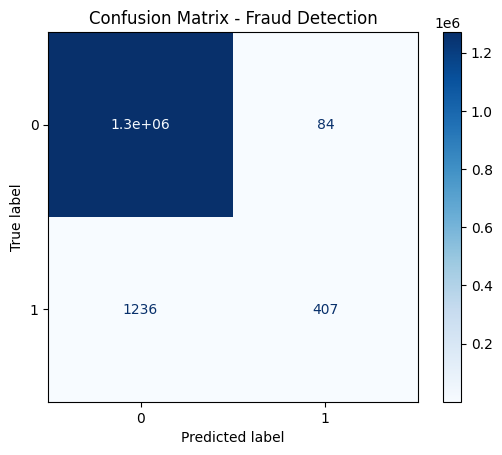

In [49]:
X_final = df_pca.drop(columns=['isFraud'])
y_final = df_pca['isFraud']

X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42, stratify=y_final)

model_xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, use_label_encoder=False, eval_metric='logloss')
model_xgb.fit(X_train, y_train)

y_pred = model_xgb.predict(X_test)

print(classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred))
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Fraud Detection')
plt.show()

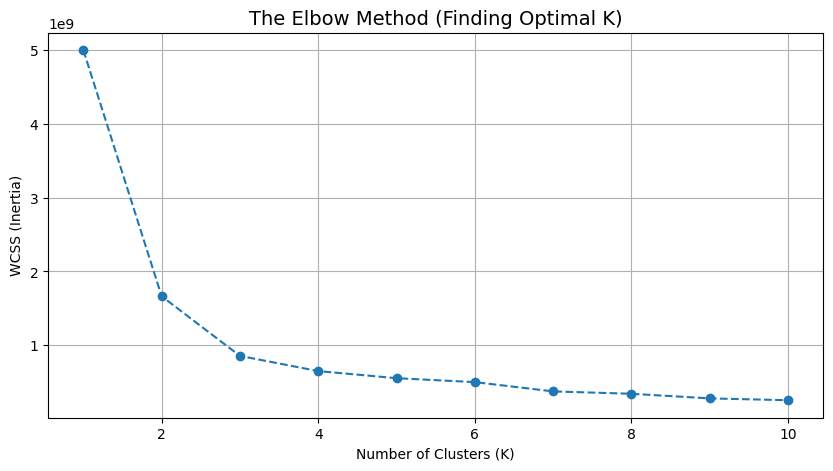

In [50]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X_pca_data = df_pca[['PC1', 'PC2', 'PC3']]

wcss = [] 
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_pca_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method (Finding Optimal K)', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

### KMeans Clustering
Introducing a new feature based on clustering to capture underlying transaction patterns.

In [51]:
optimal_k = 4 

kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
cluster_labels = kmeans_final.fit_predict(X_pca_data)

X_with_clusters = X_filtered.copy()
X_with_clusters['behavioral_segment'] = cluster_labels

print(X_with_clusters.head())

     amount  oldbalanceOrg  ...  type_TRANSFER  behavioral_segment
0 -0.332932       1.452991  ...              0                   0
1 -0.373762       0.065610  ...              0                   0
2 -0.382380      -0.130708  ...              1                   0
3 -0.382380      -0.130708  ...              0                   0
4 -0.323571       0.254820  ...              0                   0

[5 rows x 11 columns]


### Train-Test Split
Splitting the dataset into training and testing sets.

              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270881
           1       0.15      0.99      0.26      1643

    accuracy                           0.99   1272524
   macro avg       0.57      0.99      0.63   1272524
weighted avg       1.00      0.99      1.00   1272524



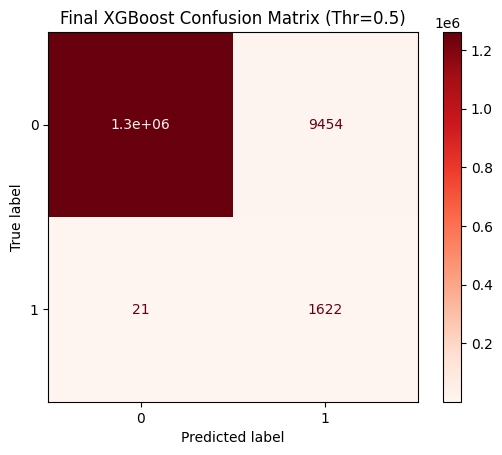

In [52]:
X_phase4 = X_with_clusters 
y_phase4 = y

X_train, X_test, y_train, y_test = train_test_split(X_phase4, y_phase4, test_size=0.2, random_state=42, stratify=y_phase4)

weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_final = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_final.fit(X_train, y_train)

y_pred_proba = xgb_final.predict_proba(X_test)[:, 1]

custom_threshold = 0.50
y_pred_final = (y_pred_proba >= custom_threshold).astype(int)

print(classification_report(y_test, y_pred_final))


disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_final))
disp.plot(cmap='Reds')
plt.title(f'Final XGBoost Confusion Matrix (Thr={custom_threshold})')
plt.show()